# 01 · Analytical Solution of the 1D Heat Equation

**PDE:**  ∂u/∂t = α ∂²u/∂x²,  x ∈ (0, L),  t > 0  
**BCs:**  u(0, t) = u(L, t) = 0  (homogeneous Dirichlet)  
**IC:**   u(x, 0) = u₀(x)

## Separation of variables
Assume `u(x,t) = X(x) T(t)`. Substituting gives

    X T' = α X'' T   ⟹   T'/(αT) = X''/X = -λ

Two ODEs:
- X'' + λ X = 0,   X(0)=X(L)=0  ⟹  λₙ = (nπ/L)²,  Xₙ = sin(nπx/L)
- T' + α λₙ T = 0   ⟹   Tₙ(t) = exp(-α λₙ t)

Superposition + Fourier series:

    u(x,t) = Σ_{n=1}^{∞} Bₙ sin(nπx/L) exp(-α (nπ/L)² t)

    Bₙ = (2/L) ∫₀ᴸ u₀(x) sin(nπx/L) dx

In [1]:
# Cell 2 — Imports & path setup
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

from heat_equation import (
    analytical_solution,
    initial_condition_sine,
    initial_condition_step,
)

rcParams["figure.dpi"] = 110
rcParams["font.size"] = 11

# Physical / numerical parameters
L     = 1.0
alpha = 0.01
Nx    = 401
x     = np.linspace(0.0, L, Nx)
dx    = x[1] - x[0]

print(f"L = {L}, α = {alpha}, Nx = {Nx}, Δx = {dx:.4f}")

L = 1.0, α = 0.01, Nx = 401, Δx = 0.0025


## 1. Initial condition and its Fourier modes
We first look at the initial profile `u₀(x)` and the first few sine modes used in the expansion.

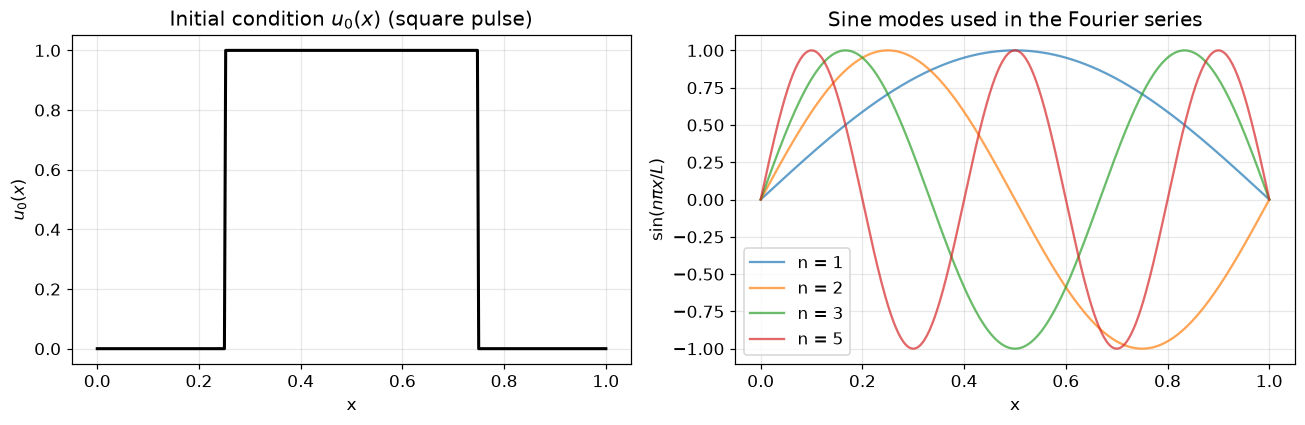

In [2]:
# Cell 4 — Initial profile and first Fourier modes
u0 = initial_condition_step(x, L, height=1.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, u0, "k", lw=2)
axes[0].set_title(r"Initial condition $u_0(x)$ (square pulse)")
axes[0].set_xlabel("x"); axes[0].set_ylabel(r"$u_0(x)$")
axes[0].grid(alpha=0.3)

for n in [1, 2, 3, 5]:
    axes[1].plot(x, np.sin(n * np.pi * x / L),
                 alpha=0.7, label=f"n = {n}")
axes[1].set_title("Sine modes used in the Fourier series")
axes[1].set_xlabel("x"); axes[1].set_ylabel(r"$\sin(n\pi x/L)$")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 2. Fourier coefficients Bₙ
For the square pulse `u₀(x) = 1` on `(L/4, 3L/4)` and 0 elsewhere, we can integrate analytically:

    Bₙ = (2/L) ∫_{L/4}^{3L/4} sin(nπx/L) dx
       = (2/(nπ)) [cos(nπ/4) - cos(3nπ/4)]

We compare this closed form with the numerical (trapezoid) quadrature.

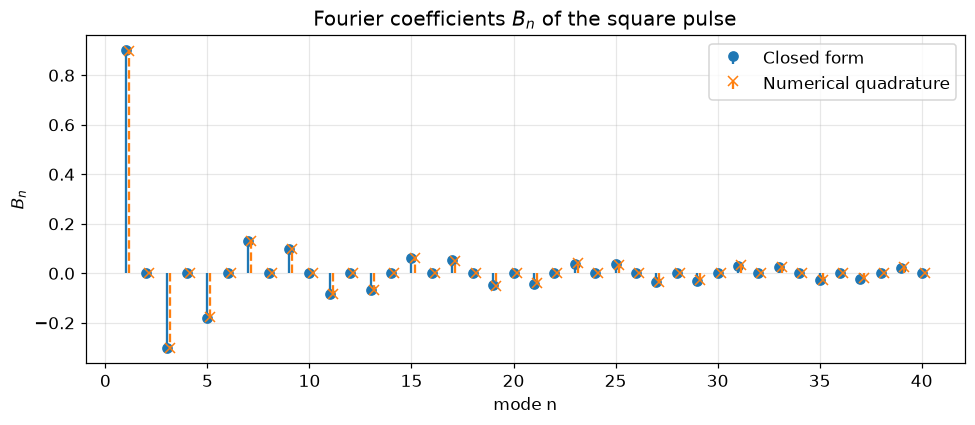

max |B_exact - B_num| = 3.707e-03


In [3]:
# Cell 6 — Fourier coefficients: closed form vs numerical quadrature
n_modes = 40
n_vals  = np.arange(1, n_modes + 1)

# Closed form for square pulse on (L/4, 3L/4)
B_exact = (2.0 / (n_vals * np.pi)) * (
    np.cos(n_vals * np.pi / 4) - np.cos(3 * n_vals * np.pi / 4)
)

# Numerical quadrature (as used inside analytical_solution)
B_num = np.array([
    (2.0 / L) * np.trapezoid(u0 * np.sin(n * np.pi * x / L), x)
    for n in n_vals
])

fig, ax = plt.subplots(figsize=(9, 4))
ax.stem(n_vals, B_exact, linefmt="C0-", markerfmt="C0o",
        basefmt=" ", label="Closed form")
ax.stem(n_vals + 0.15, B_num, linefmt="C1--", markerfmt="C1x",
        basefmt=" ", label="Numerical quadrature")
ax.set_xlabel("mode n"); ax.set_ylabel(r"$B_n$")
ax.set_title(r"Fourier coefficients $B_n$ of the square pulse")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"max |B_exact - B_num| = {np.max(np.abs(B_exact - B_num)):.3e}")

## 3. Time evolution of the analytical solution

Notice how higher modes decay faster (factor `exp(-α λₙ t)` with `λₙ ∝ n²`). The pulse smooths out almost immediately and rapidly approaches a single sine mode.

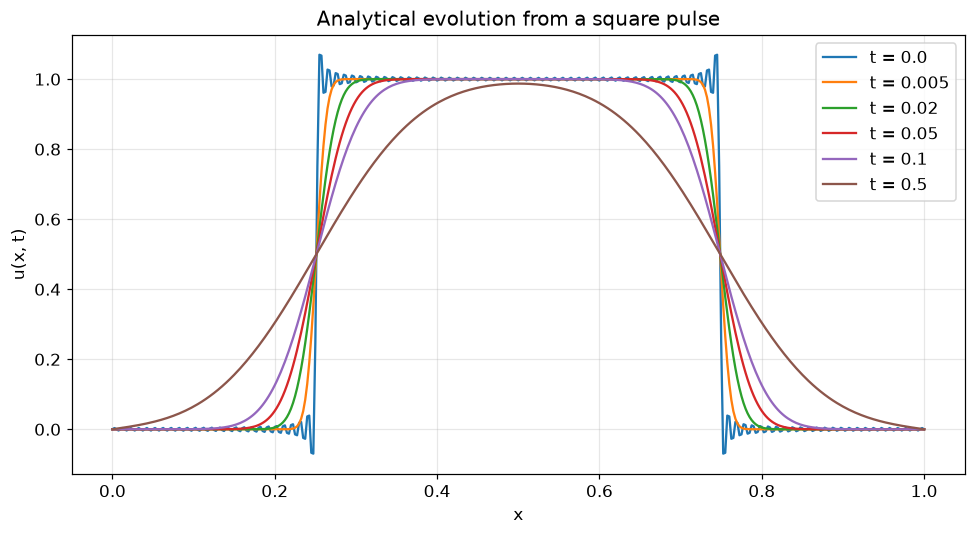

In [4]:
# Cell 8 — Analytical solution snapshots
times = [0.0, 0.005, 0.02, 0.05, 0.1, 0.5]

fig, ax = plt.subplots(figsize=(9, 5))
for t in times:
    u = analytical_solution(x, t, alpha, L, u0, n_modes=200)
    ax.plot(x, u, label=f"t = {t}")
ax.set_xlabel("x"); ax.set_ylabel("u(x, t)")
ax.set_title("Analytical evolution from a square pulse")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Validation with a single-mode IC

For `u₀(x) = sin(πx/L)` the exact solution is trivially

    u(x,t) = sin(πx/L) exp(-α π² t / L²)

We use this as a reference to confirm the Fourier-series implementation.

max error (Fourier vs closed form) = 1.110e-16


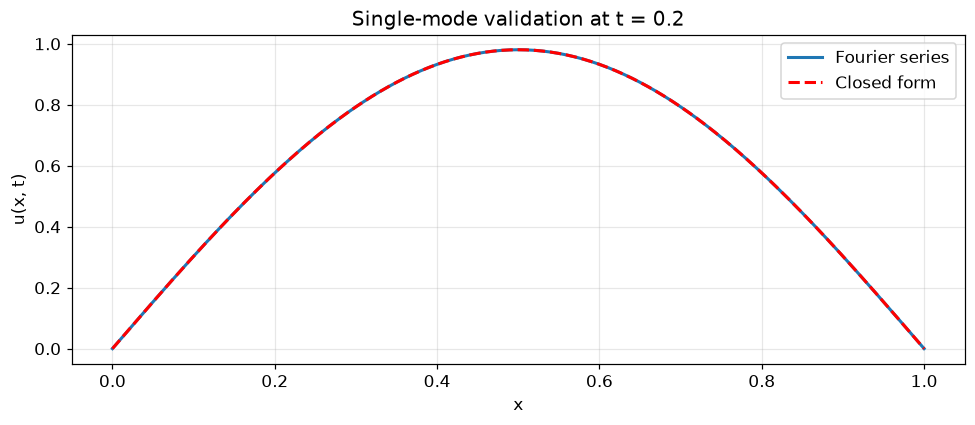

In [5]:
# Cell 10 — Single-mode analytical validation
u0_single = initial_condition_sine(x, L)
T_test    = 0.2

u_fourier = analytical_solution(x, T_test, alpha, L, u0_single, n_modes=50)
u_closed  = np.sin(np.pi * x / L) * np.exp(-alpha * np.pi**2 * T_test / L**2)

err = np.max(np.abs(u_fourier - u_closed))
print(f"max error (Fourier vs closed form) = {err:.3e}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, u_fourier, "C0-",  lw=2, label="Fourier series")
ax.plot(x, u_closed,  "r--",  lw=2, label="Closed form")
ax.set_xlabel("x"); ax.set_ylabel("u(x, t)")
ax.set_title(f"Single-mode validation at t = {T_test}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Decay of the fundamental mode

The amplitude of mode 1 decays as `exp(-α π² t / L²)`. We verify this by
tracking `max |u|` over time.

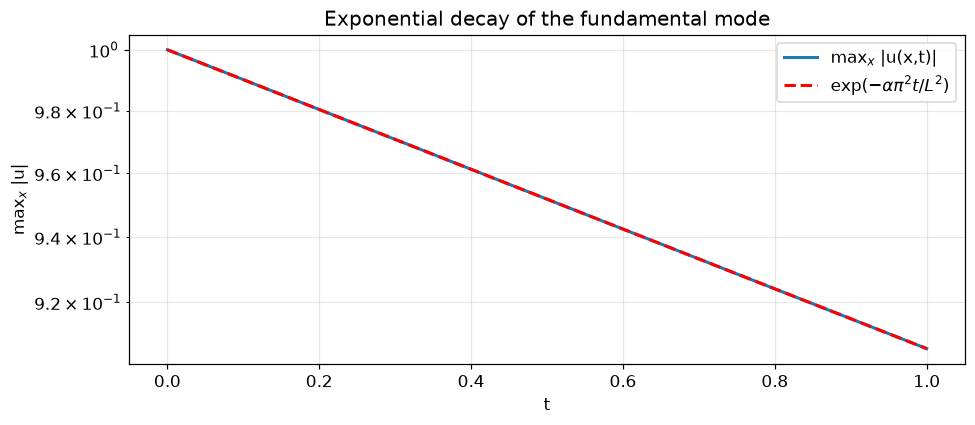

In [6]:
# Cell 12 — Exponential decay of the fundamental mode
t_vals = np.linspace(0.0, 1.0, 200)
max_u  = np.array([
    np.max(np.abs(analytical_solution(x, t, alpha, L, u0_single, n_modes=10)))
    for t in t_vals
])
theory = np.exp(-alpha * np.pi**2 * t_vals / L**2)

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(t_vals, max_u, "C0-", lw=2, label=r"max$_x$ |u(x,t)|")
ax.semilogy(t_vals, theory, "r--", lw=2,
            label=r"$\exp(-\alpha \pi^2 t / L^2)$")
ax.set_xlabel("t"); ax.set_ylabel(r"max$_x$ |u|")
ax.set_title("Exponential decay of the fundamental mode")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## 6. Effect of truncating the Fourier series

With finite `n_modes`, the square pulse exhibits Gibbs oscillations. We
quantify how the L∞ error in reconstructing `u₀` shrinks as `n_modes` grows.

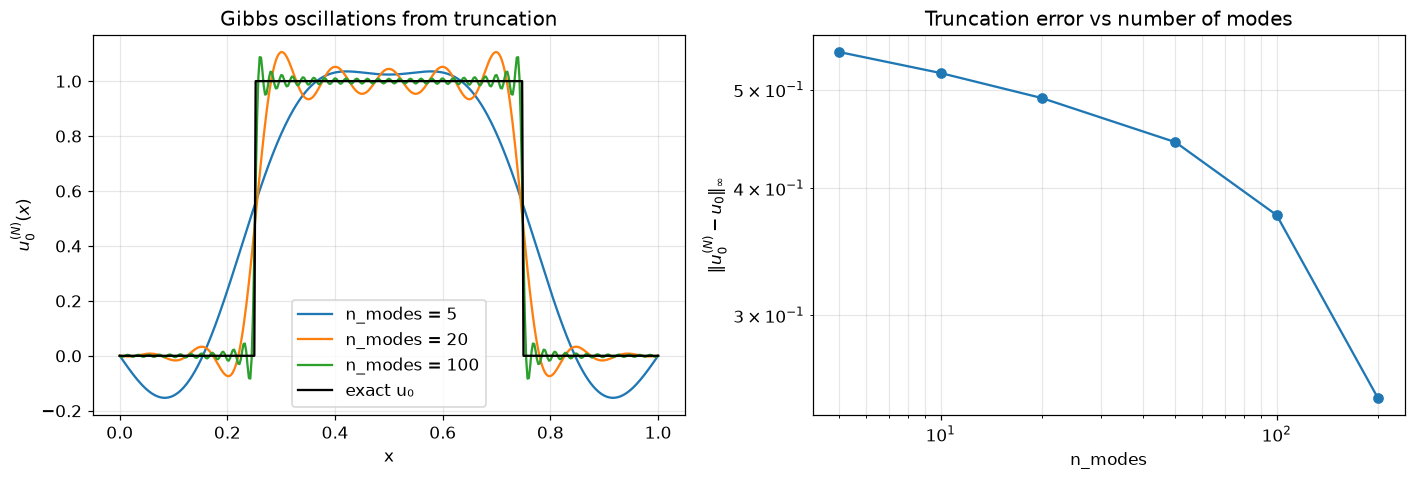

In [7]:
# Cell 14 — Gibbs oscillations & series truncation error
modes_list = [5, 10, 20, 50, 100, 200]
errs       = []
snapshots  = {}

for nm in modes_list:
    u_approx = analytical_solution(x, 0.0, alpha, L, u0, n_modes=nm)
    e = np.max(np.abs(u_approx - u0))
    errs.append(e)
    if nm in (5, 20, 100):
        snapshots[nm] = u_approx

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for nm, u_ap in snapshots.items():
    axes[0].plot(x, u_ap, label=f"n_modes = {nm}")
axes[0].plot(x, u0, "k", lw=1.5, label="exact u₀")
axes[0].set_title("Gibbs oscillations from truncation")
axes[0].set_xlabel("x"); axes[0].set_ylabel(r"$u_0^{(N)}(x)$")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].loglog(modes_list, errs, "o-")
axes[1].set_xlabel("n_modes"); axes[1].set_ylabel(r"$\|u_0^{(N)} - u_0\|_\infty$")
axes[1].set_title("Truncation error vs number of modes")
axes[1].grid(alpha=0.3, which="both")

plt.tight_layout(); plt.show()

## ✅ Summary
- Analytical solution derived via separation of variables.
- Fourier coefficients verified against a closed form.
- Truncation error decreases with the number of modes, but the square-pulse
  discontinuity induces Gibbs oscillations (O(1/N) envelope).

**Next:** `02_numerical_scheme.ipynb` — implementing the FTCS scheme.